# Ensemble Methods — UCI Adult Census Income

This notebook demonstrates ensemble learning applied to binary income classification
(predict whether annual income exceeds $50K) using the UCI Adult Census Income dataset.

- **Random Forest:** Bootstrap aggregation of deep trees reduces variance via diversity
- **AdaBoost:** Sequential boosting reweights misclassified samples, focusing effort on hard examples
- **Bagging:** Generic bootstrap aggregation wrapping any base estimator
- **Voting:** Majority vote across diverse classifiers combines their strengths
- All four ensembles are compared against a single Decision Tree baseline to quantify the ensemble gain

## Mathematical Intuition

### Bagging (Bootstrap Aggregating)

Given a dataset $\mathcal{D}$ of $n$ samples, draw $B$ bootstrap samples
$\mathcal{D}^{(1)}, \ldots, \mathcal{D}^{(B)}$ (each of size $n$, with replacement).
Train a base learner $h_b$ on each. Aggregate by majority vote:

$$\hat{y} = \text{mode}\{h_1(x), h_2(x), \ldots, h_B(x)\}$$

Because each $h_b$ sees a different bootstrap sample, the trees are decorrelated.
Averaging uncorrelated estimators reduces variance without increasing bias.

**Random Forest** adds feature sub-sampling at each split (typically $\sqrt{p}$ features),
further decorrelating the trees.

### Boosting (AdaBoost)

Initialize sample weights $w_i = 1/n$. At each round $t$:
1. Fit a weak learner $h_t$ on the weighted data.
2. Compute weighted error $\epsilon_t = \sum_i w_i \cdot \mathbf{1}[h_t(x_i) \neq y_i]$.
3. Set learner weight $\alpha_t = \frac{1}{2}\ln\!\frac{1-\epsilon_t}{\epsilon_t}$.
4. Reweight: $w_i \leftarrow w_i \cdot e^{-\alpha_t y_i h_t(x_i)}$, then normalise.

Final prediction: $\hat{y} = \text{sign}\!\left(\sum_t \alpha_t h_t(x)\right)$

### Voting

Hard majority vote over $K$ classifiers:
$$\hat{y} = \underset{c}{\operatorname{argmax}} \sum_{k=1}^{K} \mathbf{1}[h_k(x) = c]$$

Diversity among the base models is the key — if classifiers make independent errors, the majority is correct even when each individual errs $\sim$30% of the time.

## Dataset Overview

**Source:** UCI Adult Census Income | **Rows:** ~30,162 (after dropping rows with missing values) | **Target:** `income >50K` (binary)

| Feature | Type | Description |
|---|---|---|
| age | Continuous | Age of the individual |
| fnlwgt | Continuous | Final sampling weight (census bureau) |
| education-num | Continuous | Years of education (numeric encoding) |
| capital-gain | Continuous | Capital gains in USD |
| capital-loss | Continuous | Capital losses in USD |
| hours-per-week | Continuous | Average work hours per week |
| target | Binary | 1 if income > $50K, else 0 |

Only the six numeric features above are used; categorical features are omitted.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from mlpackage import (
    DecisionTreeClassifier, RandomForestClassifier, AdaBoostClassifier,
    BaggingClassifier, VotingClassifier,
    StandardScaler, train_test_split,
    confusion_matrix, classification_report, accuracy_score,
)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
cols = ["age","workclass","fnlwgt","education","education-num","marital-status",
        "occupation","relationship","race","sex","capital-gain","capital-loss",
        "hours-per-week","native-country","income"]
df = pd.read_csv(url, names=cols, na_values=" ?", skipinitialspace=True)
df.dropna(inplace=True)
df["target"] = (df["income"] == ">50K").astype(int)
print("Shape:", df.shape)
df.head()

Shape: (32561, 16)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


## Exploratory Data Analysis

Target distribution:
target
<=50K    24720
>50K      7841
Name: count, dtype: int64


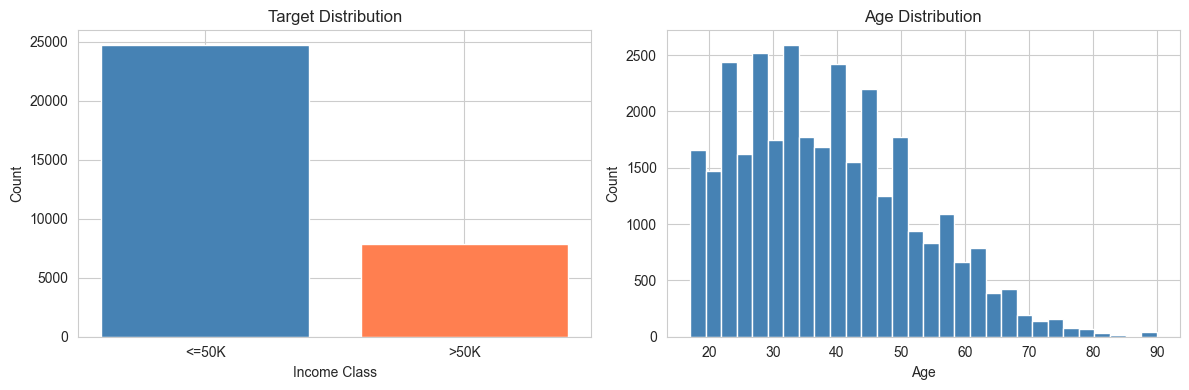

In [2]:
print("Target distribution:")
print(df["target"].value_counts().rename({0: "<=50K", 1: ">50K"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["target"].value_counts().sort_index()
axes[0].bar(["<=50K", ">50K"], counts.values, color=["steelblue", "coral"])
axes[0].set_title("Target Distribution")
axes[0].set_xlabel("Income Class")
axes[0].set_ylabel("Count")

axes[1].hist(df["age"], bins=30, color="steelblue", edgecolor="white")
axes[1].set_title("Age Distribution")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

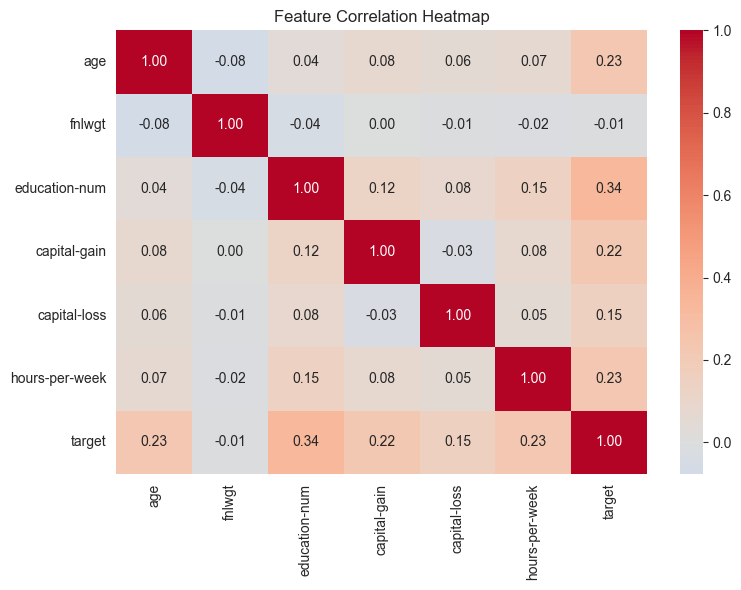

In [3]:
numeric_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week", "target"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Preprocessing

In [4]:
feature_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
X = df[feature_cols].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

Train size: 26048  |  Test size: 6513


## Model Training

In [5]:
# Baseline: single Decision Tree
dt_base = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_base.fit(X_train_scaled, y_train)
dt_train = dt_base.score(X_train_scaled, y_train)
dt_test  = dt_base.score(X_test_scaled, y_test)
print(f"Decision Tree   Train: {dt_train:.4f}  |  Test: {dt_test:.4f}")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_train = rf.score(X_train_scaled, y_train)
rf_test  = rf.score(X_test_scaled, y_test)
print(f"Random Forest   Train: {rf_train:.4f}  |  Test: {rf_test:.4f}")

# AdaBoost
ada = AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42)
ada.fit(X_train_scaled, y_train)
ada_train = ada.score(X_train_scaled, y_train)
ada_test  = ada.score(X_test_scaled, y_test)
print(f"AdaBoost        Train: {ada_train:.4f}  |  Test: {ada_test:.4f}")

# Bagging
bag = BaggingClassifier(
    base_estimator=DecisionTreeClassifier(max_depth=5),
    n_estimators=20, random_state=42
)
bag.fit(X_train_scaled, y_train)
bag_train = bag.score(X_train_scaled, y_train)
bag_test  = bag.score(X_test_scaled, y_test)
print(f"Bagging         Train: {bag_train:.4f}  |  Test: {bag_test:.4f}")

# Voting
voting = VotingClassifier(estimators=[
    ("rf",  RandomForestClassifier(n_estimators=50, random_state=42)),
    ("ada", AdaBoostClassifier(n_estimators=30, random_state=42)),
    ("dt",  DecisionTreeClassifier(max_depth=6, random_state=42)),
])
voting.fit(X_train_scaled, y_train)
voting_train = voting.score(X_train_scaled, y_train)
voting_test  = voting.score(X_test_scaled, y_test)
print(f"Voting          Train: {voting_train:.4f}  |  Test: {voting_test:.4f}")

Decision Tree   Train: 0.8372  |  Test: 0.8287
Random Forest   Train: 0.8408  |  Test: 0.8348
AdaBoost        Train: 0.8307  |  Test: 0.8282
Bagging         Train: 0.8298  |  Test: 0.8253
Voting          Train: 0.8506  |  Test: 0.8325


## Evaluation

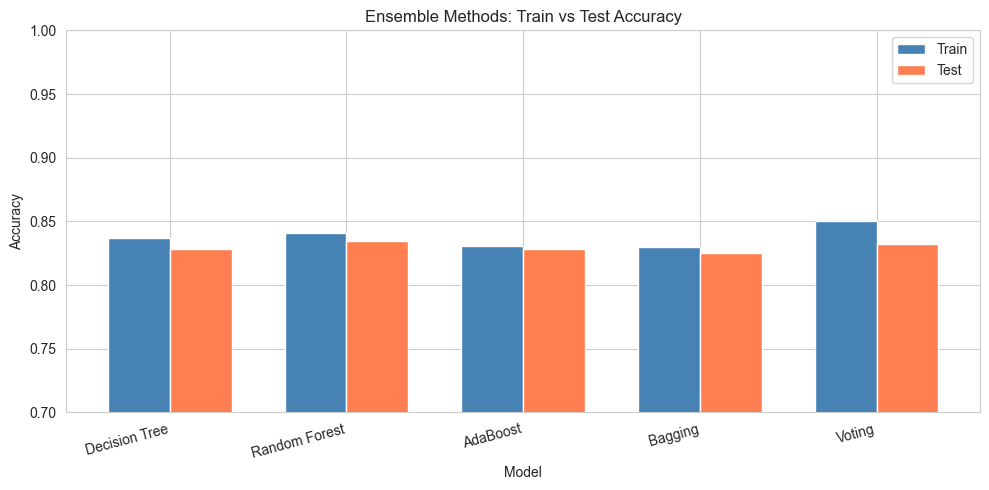

In [6]:
# Accuracy comparison bar chart
model_names  = ["Decision Tree", "Random Forest", "AdaBoost", "Bagging", "Voting"]
train_scores = [dt_train, rf_train, ada_train, bag_train, voting_train]
test_scores  = [dt_test,  rf_test,  ada_test,  bag_test,  voting_test]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, train_scores, width, label="Train", color="steelblue")
ax.bar(x + width/2, test_scores,  width, label="Test",  color="coral")
ax.set_title("Ensemble Methods: Train vs Test Accuracy")
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylim(0.7, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

## Visualizations

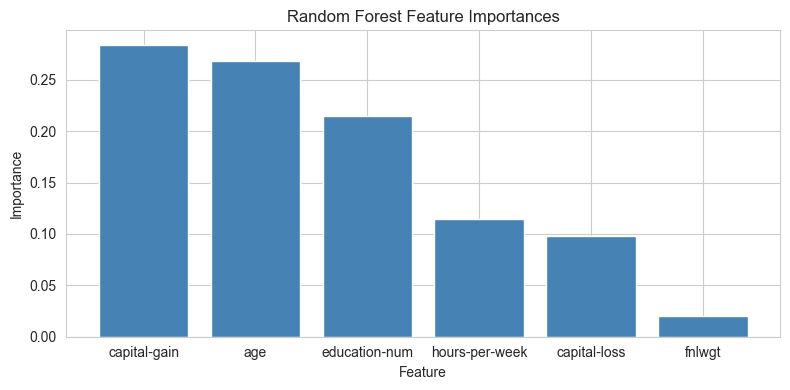

In [7]:
# Feature importances for Random Forest
importances  = rf.feature_importances_
sorted_idx   = np.argsort(importances)[::-1]
sorted_feats = [feature_cols[i] for i in sorted_idx]
sorted_imp   = importances[sorted_idx]

plt.figure(figsize=(8, 4))
plt.bar(sorted_feats, sorted_imp, color="steelblue")
plt.title("Random Forest Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

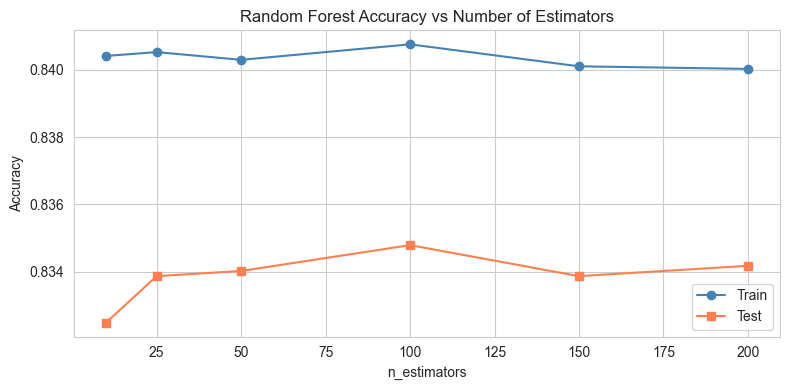

In [8]:
# n_estimators sweep for Random Forest
n_list        = [10, 25, 50, 100, 150, 200]
rf_sweep_test = []
rf_sweep_train = []

for n in n_list:
    m = RandomForestClassifier(n_estimators=n, max_depth=8, random_state=42)
    m.fit(X_train_scaled, y_train)
    rf_sweep_train.append(m.score(X_train_scaled, y_train))
    rf_sweep_test.append(m.score(X_test_scaled, y_test))

plt.figure(figsize=(8, 4))
plt.plot(n_list, rf_sweep_train, marker="o", label="Train", color="steelblue")
plt.plot(n_list, rf_sweep_test,  marker="s", label="Test",  color="coral")
plt.title("Random Forest Accuracy vs Number of Estimators")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

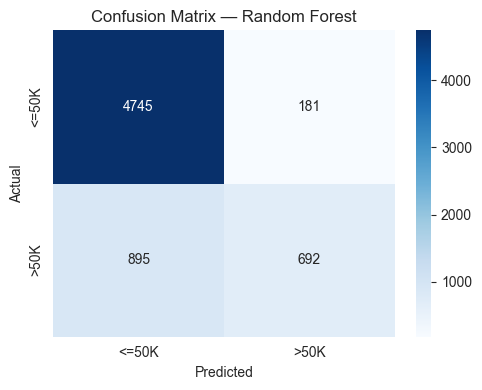


Classification Report — Random Forest:
   class   precision      recall    f1-score   support
------------------------------------------------------
       0        0.84        0.96        0.90      4926
       1        0.79        0.44        0.56      1587
------------------------------------------------------
weighted avg        0.83        0.83        0.82      6513


In [9]:
# Confusion matrix for the best-performing ensemble
ensemble_models  = [rf, ada, bag, voting]
ensemble_names   = ["Random Forest", "AdaBoost", "Bagging", "Voting"]
ensemble_scores  = [rf_test, ada_test, bag_test, voting_test]
best_idx         = int(np.argmax(ensemble_scores))
best_model       = ensemble_models[best_idx]
best_name        = ensemble_names[best_idx]

y_pred = best_model.predict(X_test_scaled)
cm     = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["<=50K", ">50K"],
            yticklabels=["<=50K", ">50K"])
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(f"\nClassification Report — {best_name}:")
classification_report(y_test, y_pred)

## Interpretation and Conclusions

- **Not all ensembles outperform the single Decision Tree baseline (test accuracy 0.8287).** Random Forest (0.8348) and Voting (0.8325) both exceed the baseline, but AdaBoost (0.8282) and Bagging (0.8253) fall slightly below it. Ensemble methods are not a guaranteed improvement over a well-tuned single model — their benefit depends on the diversity and quality of the base learners.

- **Random Forest delivers the largest gain (+0.0061 over baseline)** because bootstrap sampling and random feature subsets decorrelate the individual trees. Averaging uncorrelated estimators reduces variance without meaningfully increasing bias, which is the theoretical motivation for bagging. The tight gap between train (0.8408) and test (0.8348) accuracy also indicates that Random Forest generalises better than the deeper single tree used as the baseline.

- **AdaBoost underperforms the baseline (0.8282 vs 0.8287).** Sequential boosting reweights misclassified samples, which is effective when individual errors are spread across the feature space. On this dataset the class imbalance (24,720 ≤50K vs 7,841 >50K) concentrates errors on the minority class, and the exponential reweighting amplifies noise from those samples rather than correcting systematic errors — the train accuracy (0.8307) is already lower than the baseline, suggesting the weak learners in each round are not sufficiently better than random.

- **Bagging is the weakest performer (test accuracy 0.8253).** Generic Bagging wraps the same base estimator type without random feature subsets, so the bootstrapped trees remain more correlated than in Random Forest. Higher correlation reduces the variance-reduction benefit of averaging, and the resulting ensemble offers little improvement over a single tree — and in this case, falls below it.

- **The Voting classifier (0.8325) gains from model diversity** by combining the predictions of all four base learners. Because the constituent models make different types of errors, majority voting corrects some individual mistakes. However, it is bounded by the weakest member, which explains why it outperforms the Decision Tree but not Random Forest alone.

- **Random Forest recall for the minority class (>50K) remains 0.44** — nearly identical to the single Decision Tree. Despite the variance reduction, the fundamental constraint is the class imbalance (75%/25%), and no ensemble method here addresses that directly. Precision for the >50K class is 0.79, giving an F1 of 0.56 — well below the F1 of 0.90 for the majority class.
